In [1]:

import sys
import os
import time
import numpy as np

import MDAnalysis as mda
# from MDAnalysis.analysis import align
# from MDAnalysis.analysis import distances

import westpa
from westpa.analysis import Run

import matplotlib.pyplot as plt

In [2]:
#this barely needs to be a method but having the .h5 stuff compartmentalized is nice
def load_h5_pcs(h5path, miniter, maxiter):
    
    run = Run.open(h5path)

    #set maximum iteration automatically
    if maxiter == -1:
        maxiter = run.num_iterations

    pcs = [iteration.pcoords for iteration in run if (iteration.number >= miniter and iteration.number < maxiter)]

    return pcs

In [34]:
#specify input file

cftr_west = "/home/jonathan/Documents/grabelab/cftr/chloe-data"
cftr_refpc = "/home/jonathan/Documents/grabelab/cftr/refeaturization"

h5paths_names = [[f"{cftr_west}/wstp_cftr_1_degrabo/west-040925.h5", f"{cftr_refpc}/nonlip_glpg_1", "pyrazole-1", "blue"],
                  [f"{cftr_west}/wstp_cftr_2_wynton/west-040925.h5", f"{cftr_refpc}/nonlip_glpg_2", "pyrazole-2", "cyan"],
                  [f"{cftr_west}/wstp_lip_glpg_1/west-040925.h5", f"{cftr_refpc}/lip_glpg_1", "undecanol-1", "red"],
                  [f"{cftr_west}/wstp_lip_glpg_2/west-040925.h5", f"{cftr_refpc}/lip_glpg_2", "undecanol-2", "orange"]]

#westpa rounds to load
minround = 0
maxround = -1

run_ind = 3

data_paths = ["/home/jonathan/Documents/grabelab/cftr/revisions/abbv-974-1",
              "/home/jonathan/Documents/grabelab/cftr/revisions/abbv-974-2",
              "/home/jonathan/Documents/grabelab/cftr/revisions/cftri-c10-1",
              "/home/jonathan/Documents/grabelab/cftr/revisions/cftri-c10-2"]
data_path = data_paths[run_ind]

In [35]:
pcs_all = load_h5_pcs(h5paths_names[run_ind][0], minround, maxround)

In [36]:
nbins = 51
binbounds = np.arange(0,nbins,1)
bincenters = [(binbounds[i]+binbounds[i+1])/2 for i in range(len(binbounds)-1)]
boxdims_by_bin = [[] for a in range(nbins)]
membrane_thickness_by_bin = [[] for a in range(nbins)]

#later init_round values avoid questions about confounding time correlations but increase statistical noise
init_round = 0
final_round = 2000
#loop over WE rounds
for r in range(init_round+1,final_round,10):
    
    #get progress coordinates of the walkers, accounting for the occasional corrupted file
    pcs_flat = pcs_all[r-1][:,-1].flatten()
    walkers = np.load(f"{data_path}/pc_data_round_{r}_walker_numbers_v1.npy")
    pcs = [pcs_flat[w] for w in walkers]

    #assign frames to bins by pc
    bins = np.digitize(pcs, binbounds)

    #load water coordinates
    boxdims = np.load(f"{data_path}/pc_data_round_{r}_boxdims_v1.npy")
    membrane_thickness = np.load(f"{data_path}/pc_data_round_{r}_membrane_thickness_v1.npy")

    #get coordinates of waters in each bin
    for b, box, mem in zip(bins, boxdims, membrane_thickness):
        boxdims_by_bin[b].append(box)
        membrane_thickness_by_bin[b].append(mem)

for i, w in enumerate(boxdims_by_bin):
    print(f"{i}: {len(w)}")

mean_boxdims_by_bin = np.stack([np.mean(np.stack(w), axis=0) if len(w) > 0 else -np.ones(6) for w in boxdims_by_bin])
std_boxdims_by_bin = np.stack([np.std(np.stack(w), axis=0) if len(w) > 0 else np.zeros(6) for w in boxdims_by_bin])

mean_membrane_thickness_by_bin = [np.mean(w) if len(w) > 0 else -1 for w in membrane_thickness_by_bin]
std_membrane_thickness_by_bin = [np.std(w) if len(w) > 0 else 0 for w in membrane_thickness_by_bin]

0: 0
1: 721
2: 3533
3: 4298
4: 2302
5: 2586
6: 1376
7: 675
8: 393
9: 324
10: 320
11: 366
12: 302
13: 236
14: 188
15: 205
16: 171
17: 203
18: 194
19: 213
20: 169
21: 182
22: 153
23: 137
24: 171
25: 199
26: 269
27: 251
28: 179
29: 147
30: 93
31: 99
32: 77
33: 69
34: 59
35: 75
36: 67
37: 61
38: 58
39: 43
40: 82
41: 77
42: 47
43: 27
44: 13
45: 11
46: 7
47: 4
48: 3
49: 0
50: 0


(3.8, 4.1)

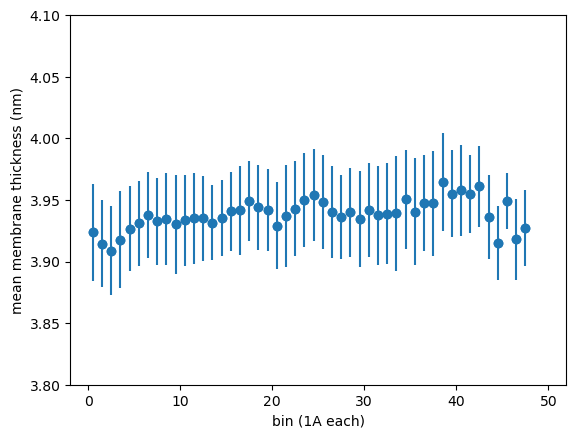

In [37]:
plt.scatter(bincenters, np.array(mean_membrane_thickness_by_bin[1:])/10)
plt.errorbar(bincenters, np.array(mean_membrane_thickness_by_bin[1:])/10, yerr=np.array(std_membrane_thickness_by_bin[1:])/10, fmt = "o")

plt.xlabel("bin (1A each)")
plt.ylabel("mean membrane thickness (nm)")
plt.ylim(3.8,4.1)

(10.1, 10.4)

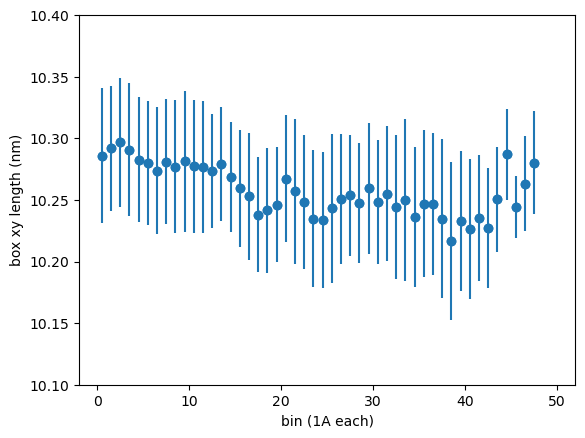

In [38]:
plt.scatter(bincenters, mean_boxdims_by_bin[1:,0]/10)
plt.errorbar(bincenters, mean_boxdims_by_bin[1:,0]/10, yerr=std_boxdims_by_bin[1:,0]/10, fmt = "o")

plt.xlabel("bin (1A each)")
plt.ylabel("box xy length (nm)")
plt.ylim(10.1,10.4)

Text(0.5, 0, 'bin (1A each)')

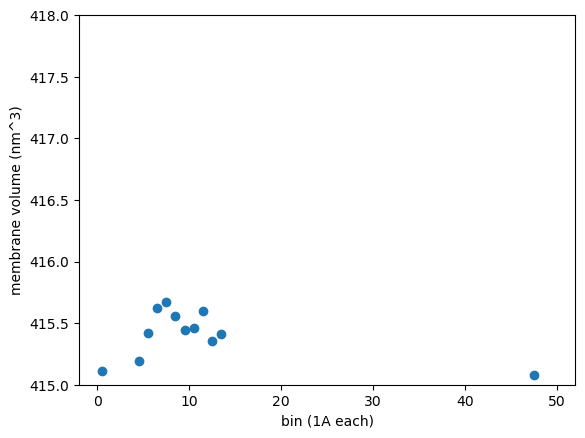

In [39]:
membrane_volume = np.product(np.stack([mean_boxdims_by_bin[1:,0], mean_boxdims_by_bin[1:,1], mean_membrane_thickness_by_bin[1:]]), axis = 0)
plt.scatter(bincenters, membrane_volume/1000)
plt.ylim(415, 418)
plt.ylabel("membrane volume (nm^3)")
plt.xlabel("bin (1A each)")
#to get more accurate values and error bars which properly reflected the width-thickness correlation would require going back to the frame-level data


Text(0, 0.5, 'box xy length (A)')

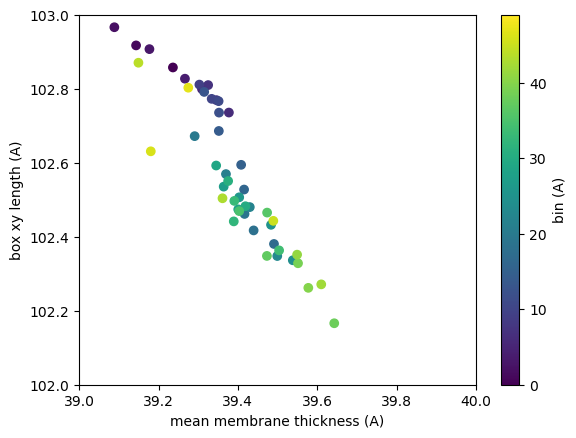

In [40]:
order_values = np.arange(len(mean_membrane_thickness_by_bin[1:]))

plt.scatter(mean_membrane_thickness_by_bin[1:], mean_boxdims_by_bin[1:,0], c = order_values)
plt.colorbar(label = "bin (A)")
plt.xlim(39,40)
plt.ylim(102,103)

plt.xlabel("mean membrane thickness (A)")
plt.ylabel("box xy length (A)")


In [80]:
def plot_to_subplot(data_path, h5path, final_round, axs, col):

    pcs_all = load_h5_pcs(h5path, minround, maxround)
    
    nbins = 51
    binbounds = np.arange(0,nbins,1)
    bincenters = [(binbounds[i]+binbounds[i+1])/2 for i in range(len(binbounds)-1)]
    boxdims_by_bin = [[] for a in range(nbins)]
    membrane_thickness_by_bin = [[] for a in range(nbins)]

    #later init_round values avoid questions about confounding time correlations but increase statistical noise
    init_round = 0
    #loop over WE rounds
    for r in range(init_round+1,final_round,10):
        
        #get progress coordinates of the walkers, accounting for the occasional corrupted file
        pcs_flat = pcs_all[r-1][:,-1].flatten()
        walkers = np.load(f"{data_path}/pc_data_round_{r}_walker_numbers_v1.npy")
        pcs = [pcs_flat[w] for w in walkers]

        #assign frames to bins by pc
        bins = np.digitize(pcs, binbounds)

        #load water coordinates
        boxdims = np.load(f"{data_path}/pc_data_round_{r}_boxdims_v1.npy")
        membrane_thickness = np.load(f"{data_path}/pc_data_round_{r}_membrane_thickness_v1.npy")

        #get coordinates of waters in each bin
        for b, box, mem in zip(bins, boxdims, membrane_thickness):
            boxdims_by_bin[b].append(box)
            membrane_thickness_by_bin[b].append(mem)

    for i, w in enumerate(boxdims_by_bin):
        print(f"{i}: {len(w)}")

    mean_boxdims_by_bin = np.stack([np.mean(np.stack(w), axis=0) if len(w) > 0 else -np.ones(6) for w in boxdims_by_bin])
    std_boxdims_by_bin = np.stack([np.std(np.stack(w), axis=0) if len(w) > 0 else np.zeros(6) for w in boxdims_by_bin])

    mean_membrane_thickness_by_bin = [np.mean(w) if len(w) > 0 else -1 for w in membrane_thickness_by_bin]
    std_membrane_thickness_by_bin = [np.std(w) if len(w) > 0 else 0 for w in membrane_thickness_by_bin]

    axs[(0,col)].scatter(bincenters, np.array(mean_membrane_thickness_by_bin[1:]))
    axs[(0,col)].errorbar(bincenters, np.array(mean_membrane_thickness_by_bin[1:]), yerr=np.array(std_membrane_thickness_by_bin[1:]), fmt = "o")
    axs[(0,col)].set_ylim(38,41)
    axs[(0,col)].set_xlim(0,40)
    
    axs[(1,col)].scatter(bincenters, mean_boxdims_by_bin[1:,0])
    axs[(1,col)].errorbar(bincenters, mean_boxdims_by_bin[1:,0], yerr=std_boxdims_by_bin[1:,0], fmt = "o")
    axs[(1,col)].set_xlim(0,40)
    axs[(1,col)].set_ylim(100,105)

    if col == 0:
        axs[0,0].set_ylabel("Membrane thickness (Å)") #r"Membrane thickness ($\AA$)")
        axs[1,0].set_ylabel("Box xy length (Å)") #r"Box xy length ($\AA$)")

    title_elements = data_path.split("/")[-1].split("-")
    if title_elements[0] == "abbv":
        ti0 = "ABBV"
    elif title_elements[0] == "cftri":
        ti0 = "CFTRi"


    axs[(1,col)].set_xlabel(f"Ligand distance from bound pose (Å) \n {ti0}-{title_elements[1].upper()} run {title_elements[2]}")


0: 0
1: 2791
2: 3366
3: 2900
4: 2488
5: 2568
6: 942
7: 645
8: 675
9: 669
10: 678
11: 671
12: 579
13: 375
14: 189
15: 152
16: 311
17: 437
18: 324
19: 369
20: 317
21: 235
22: 159
23: 204
24: 224
25: 281
26: 348
27: 245
28: 111
29: 129
30: 100
31: 47
32: 43
33: 37
34: 31
35: 37
36: 44
37: 33
38: 41
39: 35
40: 36
41: 15
42: 9
43: 7
44: 0
45: 1
46: 0
47: 0
48: 0
49: 0
50: 0
0: 0
1: 1343
2: 1401
3: 1313
4: 1113
5: 1104
6: 447
7: 240
8: 290
9: 278
10: 259
11: 318
12: 267
13: 168
14: 95
15: 60
16: 112
17: 176
18: 217
19: 186
20: 166
21: 139
22: 137
23: 160
24: 149
25: 176
26: 292
27: 259
28: 164
29: 142
30: 143
31: 91
32: 51
33: 70
34: 72
35: 67
36: 69
37: 71
38: 66
39: 77
40: 54
41: 57
42: 31
43: 13
44: 1
45: 0
46: 0
47: 0
48: 0
49: 0
50: 0
0: 0
1: 2035
2: 2935
3: 1436
4: 476
5: 439
6: 220
7: 242
8: 194
9: 160
10: 237
11: 218
12: 195
13: 116
14: 69
15: 88
16: 235
17: 236
18: 214
19: 227
20: 265
21: 301
22: 247
23: 133
24: 49
25: 71
26: 64
27: 42
28: 30
29: 16
30: 21
31: 18
32: 14
33: 6
34: 19

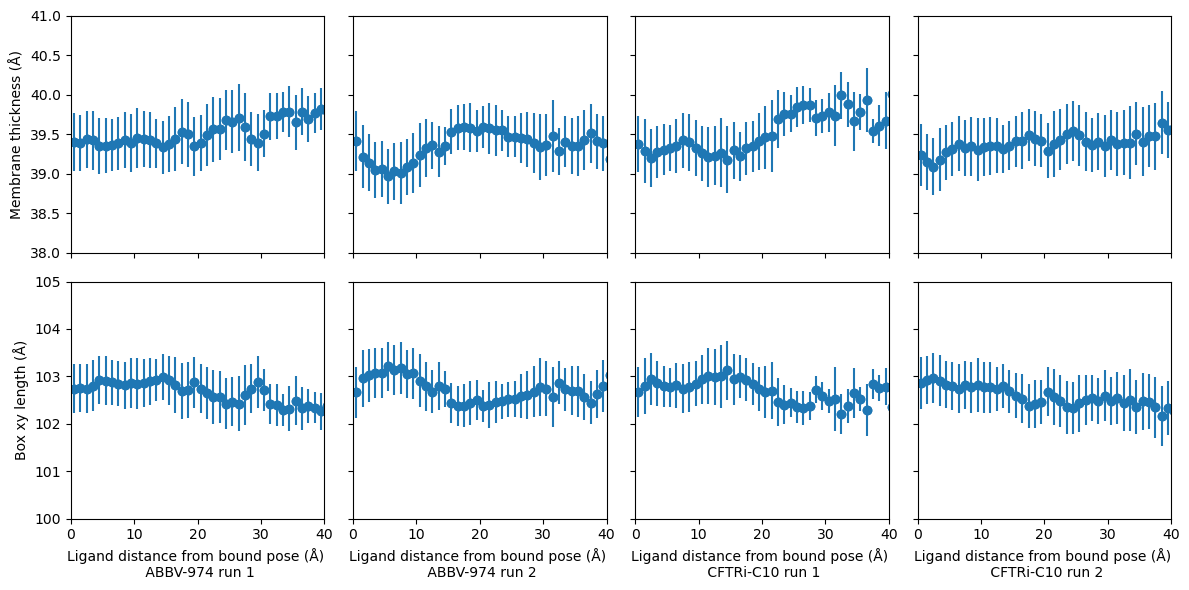

In [81]:
fig, axs = plt.subplots(2, 4, sharex='col', sharey='row', figsize=(12, 6))

maxrounds = [2000,1000,2000,2000]
for run_ind in range(4):
    # x = run_ind%2
    # y = run_ind//2
    data_path = data_paths[run_ind]
    h5path = h5paths_names[run_ind][0]
    plot_to_subplot(data_path, h5path, maxrounds[run_ind], axs, run_ind)

plt.tight_layout()
plt.savefig("/home/jonathan/Documents/grabelab/cftr/revisions/membrane_dimensions.svg", format="svg", bbox_inches="tight")